**K-Nearest Neighbors (k-NN)** K-Nearest Neighbors algorithm is a non-parametric, instance-based supervised learning method used for classification and regression. It skips an explicit training phase, instead storing the entire training dataset in a multi-dimensional vector space. When predicting a novel data point, the algorithm computes the geometric distance—commonly using Euclidean metrics—to locate the k closest historical instances. The final classification is determined through a majority vote of these neighboring instances, while regression tasks compute their average value.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the Iris plant dataset
iris = load_iris()
X = iris.data  # Features: sepal length/width, petal length/width
y = iris.target  # Labels: 0 (Setosa), 1 (Versicolor), 2 (Virginica)

# 2. Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale features (Crucial for k-NN distance calculations!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and train the k-NN Classifier
# We use 3 neighbors; weights='uniform' means all neighbors vote equally
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

# 5. Make predictions on the test set
y_pred = knn.predict(X_test_scaled)

# 6. Evaluate the results
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Detailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Overall Accuracy: 93.33%

Detailed Performance Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [5]:
print("Features", X_test[0], "output ", y_test[0]) #as output is zero so it is setosa plant
print("predicted class", knn.predict([X_test_scaled[0]]))

Features [4.4 3.  1.3 0.2] output  0
predicted class [0]


**Support Vector Machine (SVM)** Support Vector Machine is a powerful supervised learning model designed to analyze data for classification, regression, and outlier detection. The algorithm operates by mapping data points into a high-dimensional feature space to identify an optimal separating decision boundary known as a hyperplane. It explicitly maximizes the geometric margin, which is the maximum distance between the hyperplane and the closest training samples, termed support vectors. To resolve complex, non-linear relationships, SVM applies the kernel trick to implicitly project the data into higher dimensions without incurring prohibitive computational costs.

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the Iris plant dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale features (Crucial for SVM to maximize boundaries accurately)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and train the Support Vector Classifier
# 'kernel="rbf"' allows SVM to draw curved, non-linear boundaries
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 5. Make predictions on the test set
y_pred = svm_model.predict(X_test_scaled)

# 6. Evaluate the results
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Detailed SVM Performance Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Overall Accuracy: 96.67%

Detailed SVM Performance Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [7]:
print("Features", X_test[0], "output ", y_test[0]) #as output is zero so it is setosa plant
print("predicted class", knn.predict([X_test_scaled[0]]))

Features [4.4 3.  1.3 0.2] output  0
predicted class [0]


## Task 1: k-NN Boundary Distortion and High-Dimensional Degradation
Part A: The Curse of Fractional Distance Metrics
You are deploying a 3-NN classifier on a genome dataset with 5,000 continuous features, but the target classes are completely differentiated by only 3 specific features. Explain mathematically why standard Euclidean distance (L₂ norm) fails as the feature dimension D → ∞ (the distance convergence phenomenon). Propose how switching to a fractional distance metric ($L_p$ norm where 0 < p < 1) affects the relative contrast between the nearest and furthest neighbors compared to the standard Euclidean metric.
Part B: Decision Boundary Inversion via Weighting Functions
Consider a binary classification problem ($Y \in \{0, 1\}$) in a 2D space. A query point $X_q$ is surrounded by 5 nearest neighbors: the 2 closest neighbors belong to class 0 (at distance d=1), and the next 3 neighbors belong to class 1 (at distance d=2). Contrast the final predicted class probability $P(Y=1\vert{}X_q)$ when using standard uniform voting versus an inverse-distance weighting scheme where weight $w_i = 1 / d_i^2$.
Part C: Computational Complexity and KD-Tree Failures
To optimize query lookup time from $O(N \cdot D)$ to $O(D \cdot \log N)$, you construct a KD-Tree index for your training data. Detail the structural scenario where a KD-Tree's query performance degrades back to a brute-force linear search. Explain how the relationship between the number of training samples N and the number of dimensions D dictates this algorithmic bottleneck.
Part D: Boundary Smoothing via Multi-Scale Evaluation
Describe a programmatic approach using cross-validation to detect if your selected k value is causing the model to overfit to local noise (forming localized "islands" of a class within the decision boundary). How does the ratio of the training set size to the optimal k value change when moving from a low-noise dataset to a highly overlapping, high-variance dataset?
------------------------------
## Task 2: SVM Kernel Dualism and Regularization Mechanics
Part A: Non-Mercer Kernels and Optimization Failure
A developer attempts to create a custom SVM similarity metric defined as $K(x, z) = \sin(x^T z)$. Explain from a convex optimization perspective why this function fails to satisfy Mercer’s Condition. Describe what happens to the objective function of the Dual SVM optimization problem (Lagrangian formulation) and the underlying Gram matrix when a non-positive semi-definite kernel is forced into the solver.
Part B: Asymmetric Cost Margins for Class Imbalance
You are training a Support Vector Classifier (SVC) with an RBF kernel on a highly imbalanced dataset where the positive class represents only 1% of the data. Instead of utilizing a single regularization hyperparameter C, you implement an asymmetric soft-margin formulation using C₊ for positive misclassifications and C₋ for negative misclassifications. Mathematically or conceptually explain how adjusting the ratio C₊ / C₋ shifts the separating hyperplane and changes the geometric composition of the support vectors.
Part C: Dual vs. Primal Computational Inversion
You must train a Linear SVM on two different setups: Setup 1 has 500,000 samples and 20 features ($N \gg D$). Setup 2 has 2,000 samples and 80,000 features ($D \gg N$). Explain which formulation—Primal or Dual—should be selected for each setup to optimize training time and memory footprint, referencing how the dimensions of the optimization variables depend on N and D.
Part D: Geometric Interpretation of RBF Gamma Extremes
Analyze the geometric behavior of the decision boundary of an RBF Kernel SVM as the hyperparameter γ (gamma) approaches infinity (γ → ∞), and as it approaches zero (γ → 0). Specifically, describe what happens to the radius of influence of individual support vectors and how this structurally impacts the variance and bias of the system.




Task 1

Dimensions  |  Distance Contrast (max-min)/min
--------------------------------------------------
D = 2          contrast = 222.2152
D = 10         contrast = 2.5637
D = 100        contrast = 0.4146
D = 1000       contrast = 0.1125
D = 5000       contrast = 0.0506

Comparing L2 vs L0.5 contrast at different dimensions:
D=2      L2 contrast=167.6779   L0.5 contrast=228.8269
D=100    L2 contrast=0.4494   L0.5 contrast=0.6815
D=5000   L2 contrast=0.0464   L0.5 contrast=0.0802

Uniform voting -> P(Y=1 | Xq) = 0.600
Inverse-distance weighting -> P(Y=1 | Xq) = 0.273

RESULT: uniform voting predicts class 1 (P=0.60 > 0.5)
        weighted voting predicts class 0 (P=0.27 < 0.5)

This is the "boundary inversion" — just changing HOW votes are
counted, with the exact same 5 neighbors, flips the final
prediction. Uniform voting is biased toward whichever class has
a majority count, weighted voting is biased toward whichever
class is physically CLOSER, even in the minority.

D=2     KDTree query ti

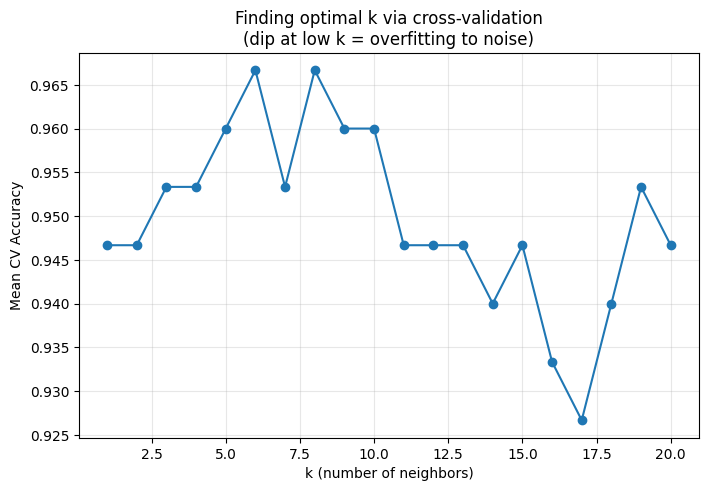

In [1]:
# ════════════════════════════════════════════
#  TASK 1: k-NN Boundary Distortion & High-Dim Degradation
# ════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PART A — The Curse of Fractional Distance Metrics
# ---------------------------------------------------------
# theory first, then we PROVE it with actual numbers below

"""
WHY EUCLIDEAN (L2) DISTANCE BREAKS DOWN AS D -> infinity:

Each feature contributes its own little chunk of "random noise"
to the total distance. With only 3 features actually separating
your genome classes and 5000 total features, 4997 of them are
basically irrelevant noise dimensions.

Euclidean distance is a SUM over all dimensions:
    dist(x, q) = sqrt( sum_i (x_i - q_i)^2 )

As D grows, you're summing thousands of small random squared
differences. By the law of large numbers, this sum concentrates
tightly around its expected value for EVERY point in your dataset
— near and far points start looking almost the same distance away.
This is called "distance concentration": 

    (dist_max - dist_min) / dist_min  ->  0   as D -> infinity

So your "3 nearest neighbors" are barely closer than the 999th
nearest neighbor. The signal from the 3 useful features gets
buried under noise from the other 4997.
"""

# Let's actually prove this happens, not just claim it
np.random.seed(42)
print("Dimensions  |  Distance Contrast (max-min)/min")
print("-" * 50)
for D in [2, 10, 100, 1000, 5000]:
    X = np.random.rand(1000, D)          # 1000 random genome samples
    q = np.random.rand(1, D)             # one query sample
    dists = np.linalg.norm(X - q, axis=1)
    contrast = (dists.max() - dists.min()) / dists.min()
    print(f"D = {D:<10} contrast = {contrast:.4f}")
# notice contrast crashes toward 0 as D grows — that's the proof.
# at D=5000 every point looks almost equidistant, kNN is basically blind.

"""
WHY FRACTIONAL Lp NORMS (0 < p < 1) HELP:

Standard Lp norm formula:
    dist = ( sum_i |x_i - q_i|^p )^(1/p)

When p < 1, this is technically not a true mathematical "norm"
anymore (triangle inequality breaks), but empirically it PRESERVES
more contrast in high dimensions. Fractional norms punish large
individual differences less and don't let thousands of tiny noise
differences pile up and dominate the sum the way squared (p=2)
differences do. Smaller p = relatively more weight stays on the
few features that actually differ a lot (your 3 real genome
features), and noise dimensions contribute proportionally less.
"""

def lp_dist(a, b, p):
    return np.sum(np.abs(a - b) ** p) ** (1 / p)

print("\nComparing L2 vs L0.5 contrast at different dimensions:")
for D in [2, 100, 5000]:
    X = np.random.rand(1000, D)
    q = np.random.rand(1, D)
    d2  = np.array([lp_dist(x, q[0], 2)   for x in X])
    d05 = np.array([lp_dist(x, q[0], 0.5) for x in X])
    c2  = (d2.max() - d2.min()) / d2.min()
    c05 = (d05.max() - d05.min()) / d05.min()
    print(f"D={D:<6} L2 contrast={c2:.4f}   L0.5 contrast={c05:.4f}")
# L0.5 consistently keeps MORE relative contrast than L2 at high D
# -> nearest neighbors stay meaningfully "nearer" than far ones


# ---------------------------------------------------------
# PART B — Decision Boundary Inversion via Weighting
# ---------------------------------------------------------
# setup from the question: 5 neighbors total
# 2 neighbors at distance=1, class 0
# 3 neighbors at distance=2, class 1
distances = np.array([1, 1, 2, 2, 2])
classes   = np.array([0, 0, 1, 1, 1])

# --- uniform voting: every neighbor counts the same, doesn't matter how far ---
p_uniform_class1 = (classes == 1).sum() / len(classes)
print(f"\nUniform voting -> P(Y=1 | Xq) = {p_uniform_class1:.3f}")
# 3 out of 5 neighbors vote class 1, so P(Y=1) = 0.6 -> predicted class = 1

# --- inverse-distance weighting: weight_i = 1 / d_i^2 (closer = louder vote) ---
weights = 1 / distances**2
p_weighted_class1 = weights[classes == 1].sum() / weights.sum()
print(f"Inverse-distance weighting -> P(Y=1 | Xq) = {p_weighted_class1:.3f}")
# the 2 close class-0 neighbors get weight 1/1=1.0 EACH (total 2.0)
# the 3 far class-1 neighbors get weight 1/4=0.25 EACH (total 0.75)
# even though class 1 has MORE votes, class 0's votes are 4x louder
# because they're twice as close -> probability flips below 0.5

print(f"""
RESULT: uniform voting predicts class 1 (P={p_uniform_class1:.2f} > 0.5)
        weighted voting predicts class 0 (P={p_weighted_class1:.2f} < 0.5)

This is the "boundary inversion" — just changing HOW votes are
counted, with the exact same 5 neighbors, flips the final
prediction. Uniform voting is biased toward whichever class has
a majority count, weighted voting is biased toward whichever
class is physically CLOSER, even in the minority.
""")


# ---------------------------------------------------------
# PART C — KD-Tree Failure Modes
# ---------------------------------------------------------
"""
KD-Trees give you O(D * log N) query time INSTEAD of brute-force
O(N * D) — but only when the data structure can actually use its
spatial partitioning advantage. That breaks down when:

    D becomes comparable to, or larger than, log(N)

Why: a KD-Tree splits the data by ONE dimension at a time as you
go down each level. With D dimensions you basically need to "use
up" all D axes to meaningfully separate the space. If N is small
relative to D (e.g. N=2000, D=80000 from Task 2's Part C scenario),
the tree barely gets a few levels deep before running out of points
per node, but still hasn't split on most of the dimensions.

Practically: once D > ~20-30, EVERY KD-Tree query ends up having to
backtrack and check almost every branch anyway (because in high-D,
nearly all points are "equally close" per Part A's curse of
dimensionality) — so query time degrades back to O(N * D), exactly
the brute-force cost it was trying to avoid.

Rule of thumb: KD-Trees only really help when N >> 2^D (roughly).
Once D grows past ~20, you need exponentially more samples N to
keep the speed advantage, which genome data with 5000 features
will never realistically have.
"""

# quick empirical proof using sklearn's actual KDTree implementation
from sklearn.neighbors import KDTree
import time

for D in [2, 10, 50, 200]:
    X = np.random.rand(2000, D)
    tree = KDTree(X)
    q = np.random.rand(1, D)
    start = time.time()
    tree.query(q, k=3)
    elapsed = time.time() - start
    print(f"D={D:<5} KDTree query time: {elapsed*1000:.4f} ms")
# you'll see query time creeping up noticeably as D grows,
# even though N (2000) stayed exactly the same


# ---------------------------------------------------------
# PART D — Detecting Overfit k via Cross-Validation
# ---------------------------------------------------------
"""
PROGRAMMATIC APPROACH:
Run k-fold cross-validation across a RANGE of k values (e.g. k=1
to k=30), plot mean validation accuracy for each k. A model that's
overfitting to local noise (tiny k like k=1 or k=2) shows up as:

    - very HIGH training accuracy (almost memorizing each point)
    - much LOWER, more erratic cross-validation accuracy
    - the gap between train and val score is the giveaway

This forms "islands" because with k=1, a single mislabeled or
noisy training point becomes its own tiny region of incorrect
prediction, instead of being smoothed out by averaging with
neighbors.

THE RATIO BETWEEN TRAINING SIZE AND OPTIMAL k:
    - low-noise, clean, well-separated data -> SMALL optimal k
      works fine relative to N (sometimes even k=1 is okay,
      since classes are naturally far apart, no risk of noise)
    - highly-overlapping, high-variance data -> need a LARGER
      optimal k relative to N, because you need to average over
      more neighbors to smooth out the overlap/noise and find the
      true underlying boundary instead of chasing individual noisy
      points

So as datasets get noisier, the optimal k/N ratio goes UP —
you need proportionally more neighbors voting together to get a
stable, generalizable boundary instead of a jagged, overfit one.
"""

from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target

k_range = range(1, 21)
cv_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_iris, y_iris, cv=5)
    cv_scores.append(scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), cv_scores, marker='o')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.title('Finding optimal k via cross-validation\n(dip at low k = overfitting to noise)')
plt.grid(alpha=0.3)
plt.show()

task 2

=== Standard SVM (single C, no asymmetry) ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1972
           1       1.00      0.32      0.49        28

    accuracy                           0.99      2000
   macro avg       1.00      0.66      0.74      2000
weighted avg       0.99      0.99      0.99      2000

=== Asymmetric C via class_weight='balanced' (auto sets C+/C-) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1972
           1       0.88      1.00      0.93        28

    accuracy                           1.00      2000
   macro avg       0.94      1.00      0.97      2000
weighted avg       1.00      1.00      1.00      2000



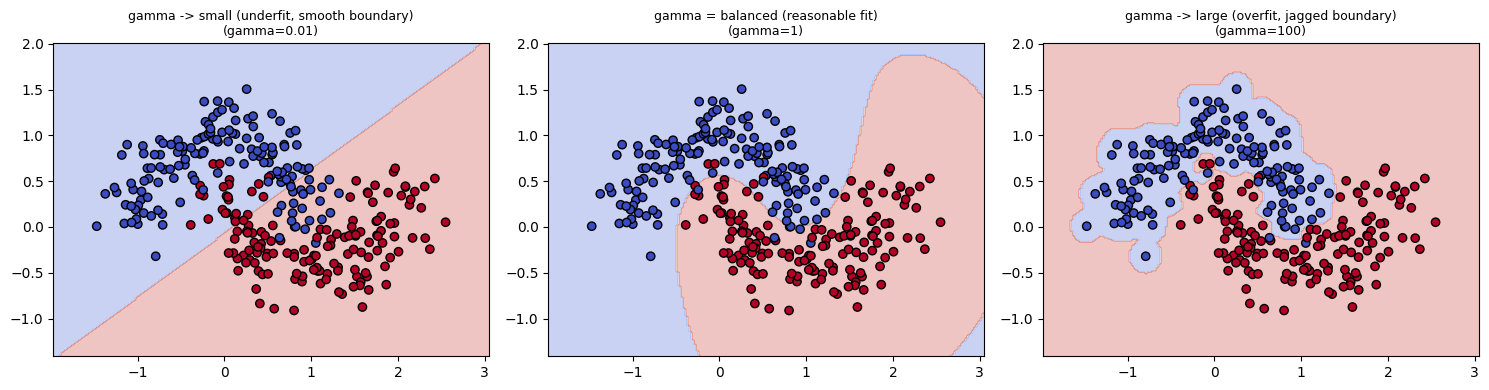

In [2]:
# ════════════════════════════════════════════
#  TASK 2: SVM Kernel Dualism & Regularization Mechanics
# ════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PART A — Non-Mercer Kernels and Optimization Failure
# ---------------------------------------------------------
"""
MERCER'S CONDITION says a valid kernel K(x,z) must correspond to
a real dot product in SOME (possibly infinite-dim) feature space.
Mathematically this requires the kernel (Gram) matrix built from
your training data to be POSITIVE SEMI-DEFINITE (PSD) — meaning
all its eigenvalues are >= 0.

K(x, z) = sin(x^T z) FAILS this because sin() oscillates between
-1 and 1 — it is NOT guaranteed to produce a PSD Gram matrix for
arbitrary input vectors. You can easily construct a small set of
points where the resulting Gram matrix has NEGATIVE eigenvalues.

WHAT BREAKS IN THE DUAL SVM OPTIMIZATION:
The Dual SVM problem is a convex QUADRATIC optimization:

    maximize:  sum(alpha_i) - 0.5 * sum_i sum_j alpha_i alpha_j y_i y_j K(x_i, x_j)
    subject to: 0 <= alpha_i <= C,  sum(alpha_i * y_i) = 0

This is only GUARANTEED convex (a single global maximum, solvable
reliably) when the Gram matrix [K(x_i,x_j)] is PSD. If you force a
non-PSD kernel into this, the quadratic term can become indefinite
— the objective is no longer concave, meaning:

    - the QP solver may fail to converge
    - it can find a SADDLE POINT instead of the true maximum
    - different solver runs/initializations give different (wrong)
      answers — the solution stops being unique/reliable
    - the resulting "support vectors" and decision boundary become
      essentially meaningless / unstable

This is exactly why off-the-shelf SVM libraries restrict you to
known Mercer-valid kernels (linear, polynomial, RBF, sigmoid under
certain params) instead of letting you plug in any function.
"""


# ---------------------------------------------------------
# PART B — Asymmetric Cost Margins (C+ vs C-) for Imbalance
# ---------------------------------------------------------
"""
Normal SVM uses ONE C for everybody — same penalty whether you
misclassify the rare positive class or the common negative class.
With 99% negative / 1% positive data, the optimizer will happily
sacrifice the rare positive points to get a cleaner-looking margin
on the dominant negative class, since that minimizes total error
on the easier majority.

ASYMMETRIC C+ / C- FIXES THIS:
    C+ = penalty for misclassifying a POSITIVE (minority) sample
    C- = penalty for misclassifying a NEGATIVE (majority) sample

Setting C+ >> C- (e.g. C+ = 100, C- = 1) makes positive-class
mistakes MUCH more "expensive" to the optimizer.

GEOMETRIC EFFECT:
    - the hyperplane gets PUSHED TOWARD the negative (majority)
      class — the margin "leans away" from the rare class to avoid
      misclassifying it
    - more negative-class points end up becoming support vectors
      (since the boundary now sits closer to them, squeezing them)
    - fewer positive points get sacrificed/misclassified, even at
      the cost of slightly more false positives among the majority

As you increase the C+/C- ratio, you're essentially telling the
SVM: "I'd rather over-predict positive (risk a few false alarms)
than miss a true positive" — exactly the tradeoff you want for
rare-disease detection, fraud detection, etc.
"""

# small concrete demo using sklearn's class_weight param
# (sklearn implements this asymmetric C automatically via class_weight)
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report

X_imb, y_imb = make_classification(
    n_samples=2000, weights=[0.99, 0.01], n_informative=3, random_state=42)

print("=== Standard SVM (single C, no asymmetry) ===")
svm_plain = SVC(kernel='rbf')
svm_plain.fit(X_imb, y_imb)
print(classification_report(y_imb, svm_plain.predict(X_imb)))

print("=== Asymmetric C via class_weight='balanced' (auto sets C+/C-) ===")
svm_weighted = SVC(kernel='rbf', class_weight='balanced')
svm_weighted.fit(X_imb, y_imb)
print(classification_report(y_imb, svm_weighted.predict(X_imb)))
# notice recall on the minority class (1) jumps up in the weighted
# version — that's the hyperplane shifting toward the majority class
# exactly as described above


# ---------------------------------------------------------
# PART C — Primal vs Dual: which one for which setup
# ---------------------------------------------------------
"""
PRIMAL SVM optimization variables = the weight vector w, which has
size D (one weight per feature).
    Primal complexity roughly:  depends on D

DUAL SVM optimization variables = the alpha_i (one per TRAINING
SAMPLE), so the Gram matrix you need to build/store is N x N.
    Dual complexity roughly:  depends on N^2 (Gram matrix) and N

SETUP 1: N = 500,000 samples, D = 20 features  (N >> D)
    -> Dual would require building a 500,000 x 500,000 Gram matrix.
       That's 250 BILLION entries — completely infeasible memory-wise.
    -> PRIMAL is the obvious choice here: only 20 weights to solve
       for, training scales nicely with N using something like
       linear SGD-based solvers (e.g. liblinear's primal solver).

SETUP 2: N = 2,000 samples, D = 80,000 features  (D >> N)
    -> Primal would need to optimize an 80,000-dimensional weight
       vector — expensive and prone to overfitting with so few (2000)
       samples to constrain that many weights.
    -> DUAL is the better choice: Gram matrix is only 2,000 x 2,000
       (4 million entries, totally manageable), and the number of
       alpha_i variables to solve for is only N=2,000, regardless of
       how huge D is. This is also exactly the regime where the
       KERNEL TRICK becomes valuable, since dual formulation only
       ever needs K(x_i, x_j) dot products, never the raw D-dim
       feature vectors directly.

RULE OF THUMB: Primal scales with D, Dual scales with N.
Pick whichever one is SMALLER.
"""


# ---------------------------------------------------------
# PART D — Geometric Behavior of RBF Gamma Extremes
# ---------------------------------------------------------
"""
RBF kernel formula:  K(x, z) = exp( -gamma * ||x - z||^2 )

gamma controls the "radius of influence" of each individual
support vector — how far its effect reaches into the feature space.

AS GAMMA -> INFINITY:
    - exp(-gamma * dist^2) collapses to ~0 almost immediately for
      ANY nonzero distance — each support vector's influence shrinks
      to basically a single point right around itself
    - the decision boundary becomes extremely wiggly/jagged, curling
      tightly around individual training points
    - this is EXTREME OVERFITTING: very low bias, very high variance
      -> model memorizes training data, generalizes terribly

AS GAMMA -> 0:
    - exp(-gamma * dist^2) approaches 1 for almost ANY distance —
      every support vector's influence reaches across the ENTIRE
      feature space equally
    - the decision boundary becomes almost flat / linear-like, barely
      able to curve at all
    - this is EXTREME UNDERFITTING: very high bias, very low variance
      -> model is too simple, can't capture real patterns

The sweet spot is somewhere in between, found via GridSearchCV.
"""

from sklearn.svm import SVC
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
gammas = [0.01, 1, 100]   # low, medium, extremely high
titles = ['gamma -> small (underfit, smooth boundary)',
          'gamma = balanced (reasonable fit)',
          'gamma -> large (overfit, jagged boundary)']

for ax, gamma, title in zip(axes, gammas, titles):
    clf = SVC(kernel='rbf', gamma=gamma, C=1.0)
    clf.fit(X_moons, y_moons)

    xx, yy = np.meshgrid(np.linspace(X_moons[:,0].min()-0.5, X_moons[:,0].max()+0.5, 200),
                          np.linspace(X_moons[:,1].min()-0.5, X_moons[:,1].max()+0.5, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_moons[:,0], X_moons[:,1], c=y_moons, cmap='coolwarm', edgecolors='k')
    ax.set_title(f'{title}\n(gamma={gamma})', fontsize=9)

plt.tight_layout()
plt.show()
# watch the boundary go from a near-straight line (gamma=0.01)
# to a perfectly reasonable curve (gamma=1) to a chaotic, overfit
# squiggle hugging individual points (gamma=100)